# MLP 

In [51]:
!pip install torch seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [52]:
from pathlib import Path
import json

import joblib
import pandas as pd 
import numpy as np
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [32]:
DATA_DIR = Path("data")
OUT_DIR = Path("artifacts/mlp")
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "cancer_train_scaled.csv")
val_df = pd.read_csv(DATA_DIR / "cancer_val_scaled.csv")
test_df = pd.read_csv(DATA_DIR / "cancer_test_scaled.csv")

In [33]:
train_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-1.228111,-1.336440,-1.113713,-1.061035,2.142820,2.103200,0.310883,0.526086,0.876261,4.419088,...,-1.148444,-1.089877,-0.946685,3.001625,0.632022,0.032140,-0.115310,-0.106496,2.766617,1
1,0.061953,0.560834,0.090635,-0.038141,0.123469,0.062060,0.467365,0.163457,0.263393,-0.270717,...,0.748301,0.277599,-0.124255,0.531359,0.978502,1.052185,0.431384,1.035218,0.895634,0
2,-0.420341,-0.633255,-0.414612,-0.482766,1.424532,0.038068,-0.400094,-0.420527,0.470058,0.391293,...,-0.631150,-0.586548,-0.556140,1.122459,-0.520099,-0.427396,-0.459051,0.365248,-0.495308,1
3,0.219897,-0.991481,0.132671,0.097205,-0.876951,-1.038606,-0.700156,-0.606374,-0.541886,-1.326942,...,-1.219264,-0.146719,-0.192980,-0.822876,-0.966003,-0.781024,-0.526065,-0.896322,-1.241563,1
4,-0.832123,-0.078225,-0.739063,-0.808220,1.854024,2.010924,0.909336,0.357111,1.371543,2.210122,...,1.127034,-0.437597,-0.632714,3.786817,4.076333,2.495417,2.014151,1.900338,2.975098,0


In [ ]:
# Split into features / target
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_val, y_val     = val_df.iloc[:, :-1].values, val_df.iloc[:, -1].values
X_test, y_test   = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

Convert to tensors for torch 

In [35]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

Prepare dataloaders

In [36]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=256,
    shuffle=False
)

## Simple mlp + training

In [53]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return self.net(x)

In [61]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP(X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [62]:
best_val_loss = float("inf")
patience = 20
counter = 0
best_state = None

In [63]:
for epoch in range(200):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 0: train_loss=0.6666, val_loss=0.6101
Epoch 1: train_loss=0.5560, val_loss=0.5161
Epoch 2: train_loss=0.4599, val_loss=0.4154
Epoch 3: train_loss=0.3556, val_loss=0.3181
Epoch 4: train_loss=0.2562, val_loss=0.2415
Epoch 5: train_loss=0.1873, val_loss=0.1906
Epoch 6: train_loss=0.1431, val_loss=0.1590
Epoch 7: train_loss=0.1258, val_loss=0.1363
Epoch 8: train_loss=0.0980, val_loss=0.1192
Epoch 9: train_loss=0.0843, val_loss=0.1069
Epoch 10: train_loss=0.0752, val_loss=0.0962
Epoch 11: train_loss=0.0819, val_loss=0.0887
Epoch 12: train_loss=0.0655, val_loss=0.0824
Epoch 13: train_loss=0.0577, val_loss=0.0776
Epoch 14: train_loss=0.0770, val_loss=0.0750
Epoch 15: train_loss=0.0545, val_loss=0.0727
Epoch 16: train_loss=0.0681, val_loss=0.0711
Epoch 17: train_loss=0.0485, val_loss=0.0695
Epoch 18: train_loss=0.0418, val_loss=0.0680
Epoch 19: train_loss=0.0390, val_loss=0.0674
Epoch 20: train_loss=0.0386, val_loss=0.0667
Epoch 21: train_loss=0.0369, val_loss=0.0657
Epoch 22: train_loss

In [64]:
model.load_state_dict(best_state)

<All keys matched successfully>

## Evaluation 

In [65]:
model.eval()

with torch.no_grad():
    logits = model(X_test.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    accuracy = (preds.cpu() == y_test).float().mean()

print("Test accuracy:", accuracy.item())

Test accuracy: 0.9561403393745422


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [67]:
model.eval()

with torch.no_grad():
    logits = model(X_test.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs > 0.5).astype(int)

y_true = y_test.cpu().numpy().flatten()

In [68]:
precision = precision_score(y_true, preds)
recall = recall_score(y_true, preds)
f1 = f1_score(y_true, preds)
roc_auc = roc_auc_score(y_true, probs)

In [69]:
print(f"Precision:{precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Precision:0.9855
Recall: 0.9444
F1-score: 0.9645
ROC-AUC: 0.9934


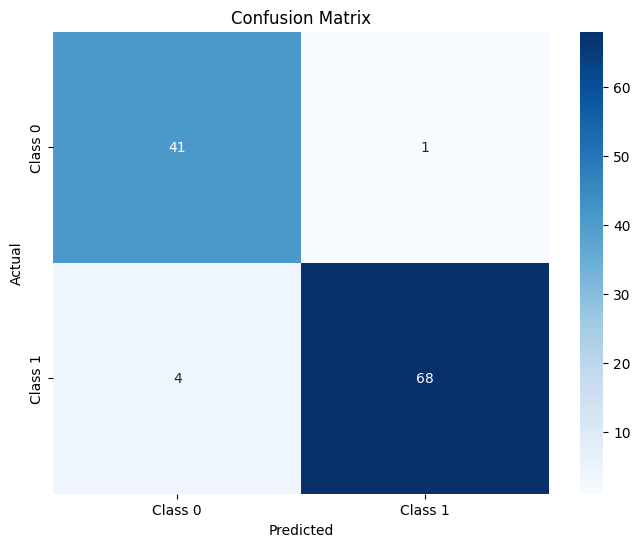

In [70]:
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import json

class MLPWrapper:
    """Wraps a PyTorch MLP so it behaves like an sklearn classifier."""

    def __init__(self, mlp_model, device):
        self.model = mlp_model
        self.device = device

    def predict_proba(self, X):
        """Return class probabilities; shape (n_samples, 2)."""
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(np.asarray(X, dtype=np.float32)).to(self.device)
            probs1 = torch.sigmoid(self.model(t)).cpu().numpy().flatten()
        return np.column_stack([1.0 - probs1, probs1])


wrapper = MLPWrapper(model, device)

torch.save(model.state_dict(), OUT_DIR / "model_state.pt")

# Save architecture config so other notebooks can rebuild the exact same model
config = {"input_dim": int(X_train.shape[1])}
(OUT_DIR / "model_config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

# Also keep the joblib file for notebooks that still reference it
joblib.dump(wrapper, OUT_DIR / "model.joblib")

print("Saved model_state.pt, model_config.json, model.joblib to", OUT_DIR)

['artifacts/mlp/model.joblib']